# Jackson 2.12: Poisson Integral for a Cylinder

This notebook works through the Chapter 2 problem that starts from the separated solution of Laplace's equation in polar coordinates and sums the Fourier series into Poisson's integral for a circular boundary.

The statement is: given the potential on the cylindrical surface $\rho=b$, derive the potential inside the cylinder in the form

$$
\Phi(\rho,\phi)=\frac{1}{2\pi}\int_0^{2\pi} \Phi(b,\phi')\,\frac{b^2-\rho^2}{b^2+\rho^2-2b\rho\cos(\phi'-\phi)}\,d\phi'.
$$

Then we ask what changes for the exterior region, the space between the cylinder and infinity.


## Physics and Separation of Variables

With no $z$ dependence, Laplace's equation in polar coordinates is

$$
\frac{1}{\rho}\frac{\partial}{\partial \rho}\left(\rho\frac{\partial \Phi}{\partial \rho}\right)+\frac{1}{\rho^2}\frac{\partial^2\Phi}{\partial\phi^2}=0.
$$

Assume a separated form $\Phi(\rho,\phi)=R(\rho)\Theta(\phi)$. Standard separation gives the angular functions $\cos n\phi$ and $\sin n\phi$, together with the radial behaviors $\rho^n$ and $\rho^{-n}$ for $n\ge 1$.

For the **interior problem** $0\le \rho < b$, regularity at the origin removes the singular pieces, so the solution has the form

$$
\Phi_{\rm in}(\rho,\phi)=a_0+\sum_{n=1}^{\infty}\left(\frac{\rho}{b}\right)^n\big[a_n\cos(n\phi)+b_n\sin(n\phi)\big].
$$

On the boundary $\rho=b$, the prescribed potential is simply its Fourier series,

$$
V(\phi)\equiv \Phi(b,\phi)=a_0+\sum_{n=1}^{\infty}\big[a_n\cos(n\phi)+b_n\sin(n\phi)\big],
$$

with coefficients

$$
a_n=\frac{1}{\pi}\int_0^{2\pi}V(\phi')\cos(n\phi')\,d\phi',
\qquad
b_n=\frac{1}{\pi}\int_0^{2\pi}V(\phi')\sin(n\phi')\,d\phi'.
$$


## From the Fourier Series to Poisson's Kernel

Insert the coefficient formulas back into the interior series and collect terms. Using the angle-difference identity,

$$
\cos(n\phi)\cos(n\phi')+\sin(n\phi)\sin(n\phi')=\cos\big(n(\phi-\phi')\big),
$$

the potential becomes

$$
\Phi_{\rm in}(\rho,\phi)=\frac{1}{2\pi}\int_0^{2\pi}V(\phi')\left[1+2\sum_{n=1}^{\infty}\left(\frac{\rho}{b}\right)^n\cos\big(n(\phi-\phi')\big)\right]d\phi'.
$$

Now define $r=\rho/b<1$ and use the standard trigonometric sum

$$
1+2\sum_{n=1}^{\infty} r^n\cos(n\theta)=\frac{1-r^2}{1-2r\cos\theta+r^2}.
$$

This gives Poisson's integral for the disk,

$$
\Phi_{\rm in}(\rho,\phi)=\frac{1}{2\pi}\int_0^{2\pi}V(\phi')\,\frac{b^2-\rho^2}{b^2+\rho^2-2b\rho\cos(\phi'-\phi)}\,d\phi'.
$$

For the **exterior problem** $\rho>b$, the logic changes only in the radial behavior. Regularity at the origin no longer matters; instead we discard the growing and logarithmic pieces so the solution stays bounded as $\rho\to\infty$. The harmonic series becomes

$$
\Phi_{\rm out}(\rho,\phi)=A_\infty+\sum_{n=1}^{\infty}\left(\frac{b}{\rho}\right)^n\big[a_n\cos(n\phi)+b_n\sin(n\phi)\big],
$$

where $A_\infty$ is the constant value approached at infinity. If we demand $\Phi\to 0$ as $\rho\to\infty$, then $A_\infty=0$ and the boundary data must have zero average. Summing the series gives the exterior Poisson kernel,

$$
\Phi_{\rm out}(\rho,\phi)=A_\infty+\frac{1}{2\pi}\int_0^{2\pi}V(\phi')\,\frac{\rho^2-b^2}{\rho^2+b^2-2b\rho\cos(\phi'-\phi)}\,d\phi'.
$$


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

plt.style.use("seaborn-v0_8-whitegrid")


In [3]:
b = 1.0


def boundary_potential(phi):
    """A zero-mean boundary potential so the exterior solution can decay at infinity."""
    return np.cos(phi) - 0.45 * np.sin(2.0 * phi) + 0.25 * np.cos(3.0 * phi)


def phi_in_series(rho, phi, b=1.0):
    r = np.asarray(rho) / b
    return r * np.cos(phi) - 0.45 * r**2 * np.sin(2.0 * phi) + 0.25 * r**3 * np.cos(3.0 * phi)


def phi_out_series(rho, phi, b=1.0):
    q = b / np.asarray(rho)
    return q * np.cos(phi) - 0.45 * q**2 * np.sin(2.0 * phi) + 0.25 * q**3 * np.cos(3.0 * phi)


def poisson_kernel_interior(rho, delta, b=1.0):
    return (b**2 - rho**2) / (b**2 + rho**2 - 2.0 * b * rho * np.cos(delta))


def poisson_kernel_exterior(rho, delta, b=1.0):
    return (rho**2 - b**2) / (rho**2 + b**2 - 2.0 * b * rho * np.cos(delta))


def poisson_integral_interior(rho, phi_eval, phi_samples, boundary_values, b=1.0):
    dphi = 2.0 * np.pi / phi_samples.size
    kernel = poisson_kernel_interior(rho, phi_samples - phi_eval, b=b)
    return np.sum(boundary_values * kernel) * dphi / (2.0 * np.pi)


def poisson_integral_exterior(rho, phi_eval, phi_samples, boundary_values, b=1.0, phi_infty=0.0):
    dphi = 2.0 * np.pi / phi_samples.size
    kernel = poisson_kernel_exterior(rho, phi_samples - phi_eval, b=b)
    return phi_infty + np.sum(boundary_values * kernel) * dphi / (2.0 * np.pi)


phi_samples = np.linspace(0.0, 2.0 * np.pi, 2048, endpoint=False)
boundary_samples = boundary_potential(phi_samples)
print(f"Boundary mean value: {boundary_samples.mean():+.3e}")


Boundary mean value: -4.163e-17


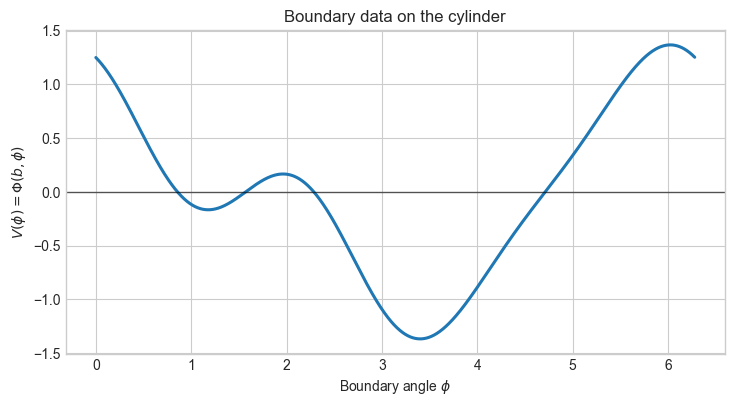

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(phi_samples, boundary_samples, color="tab:blue", lw=2.2)
ax.axhline(0.0, color="black", lw=1.0, alpha=0.6)
ax.set_xlabel(r"Boundary angle $\phi$")
ax.set_ylabel(r"$V(\phi)=\Phi(b,\phi)$")
ax.set_title("Boundary data on the cylinder")
plt.show()


In [5]:
interior_points = [(0.15, 0.40), (0.55, 1.20), (0.82, 4.10)]
exterior_points = [(1.15, 0.70), (1.70, 2.40), (2.40, 5.60)]

interior_errors = []
for rho, phi in interior_points:
    integral_value = poisson_integral_interior(rho, phi, phi_samples, boundary_samples, b=b)
    series_value = phi_in_series(rho, phi, b=b)
    interior_errors.append(abs(integral_value - series_value))

exterior_errors = []
for rho, phi in exterior_points:
    integral_value = poisson_integral_exterior(rho, phi, phi_samples, boundary_samples, b=b)
    series_value = phi_out_series(rho, phi, b=b)
    exterior_errors.append(abs(integral_value - series_value))

print(f"Max interior error (Poisson integral vs. harmonic series): {max(interior_errors):.3e}")
print(f"Max exterior error (Poisson integral vs. harmonic series): {max(exterior_errors):.3e}")


Max interior error (Poisson integral vs. harmonic series): 6.661e-16
Max exterior error (Poisson integral vs. harmonic series): 1.665e-16


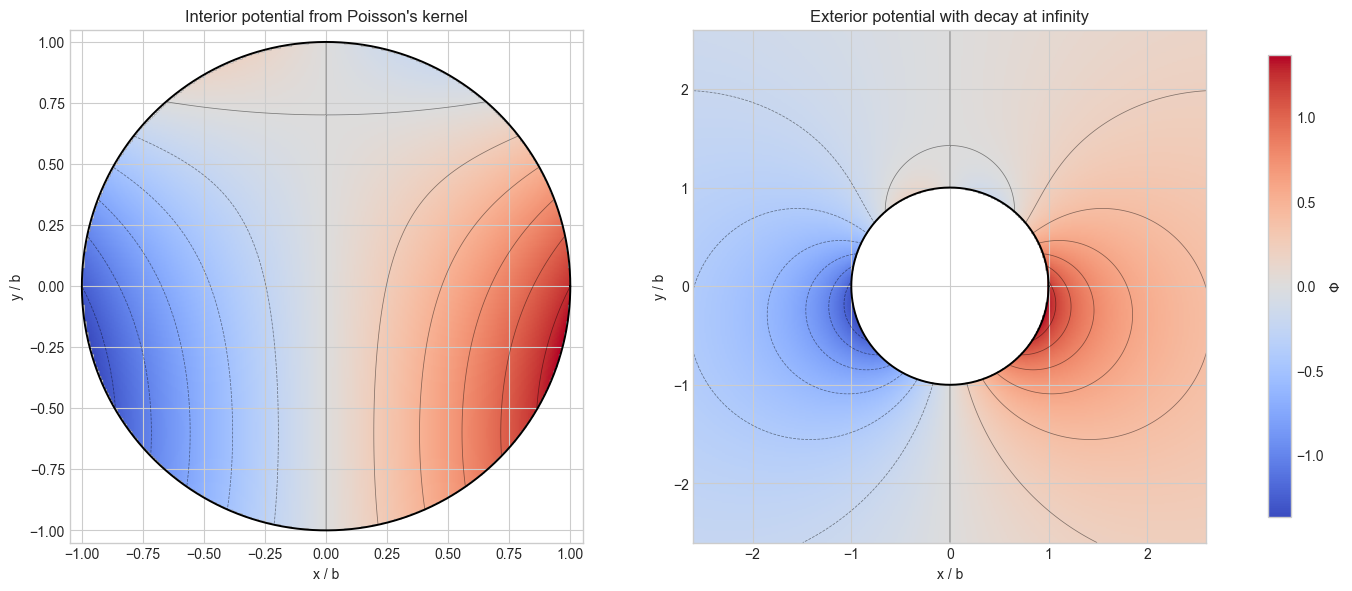

In [6]:
n_in = 280
x_in = np.linspace(-1.05 * b, 1.05 * b, n_in)
y_in = np.linspace(-1.05 * b, 1.05 * b, n_in)
X_in, Y_in = np.meshgrid(x_in, y_in, indexing="xy")
R_in = np.hypot(X_in, Y_in)
Phi_angle_in = np.arctan2(Y_in, X_in)
inside_mask = R_in <= b

phi_in = np.full_like(R_in, np.nan, dtype=float)
phi_in[inside_mask] = phi_in_series(R_in[inside_mask], Phi_angle_in[inside_mask], b=b)

n_out = 320
extent_out = 2.6 * b
x_out = np.linspace(-extent_out, extent_out, n_out)
y_out = np.linspace(-extent_out, extent_out, n_out)
X_out, Y_out = np.meshgrid(x_out, y_out, indexing="xy")
R_out = np.hypot(X_out, Y_out)
Phi_angle_out = np.arctan2(Y_out, X_out)
outside_mask = R_out >= b

phi_out = np.full_like(R_out, np.nan, dtype=float)
phi_out[outside_mask] = phi_out_series(R_out[outside_mask], Phi_angle_out[outside_mask], b=b)

vmax = max(np.nanmax(np.abs(phi_in)), np.nanmax(np.abs(phi_out)))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
theta = np.linspace(0.0, 2.0 * np.pi, 600)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), constrained_layout=True)

im0 = axes[0].imshow(
    phi_in,
    origin="lower",
    extent=(x_in.min(), x_in.max(), y_in.min(), y_in.max()),
    cmap="coolwarm",
    norm=norm,
)
axes[0].contour(X_in, Y_in, phi_in, levels=12, colors="black", linewidths=0.55, alpha=0.45)
axes[0].plot(b * np.cos(theta), b * np.sin(theta), color="black", lw=1.4)
axes[0].set_title("Interior potential from Poisson's kernel")
axes[0].set_xlabel("x / b")
axes[0].set_ylabel("y / b")
axes[0].set_aspect("equal")

im1 = axes[1].imshow(
    phi_out,
    origin="lower",
    extent=(x_out.min(), x_out.max(), y_out.min(), y_out.max()),
    cmap="coolwarm",
    norm=norm,
)
axes[1].contour(X_out, Y_out, phi_out, levels=14, colors="black", linewidths=0.55, alpha=0.45)
axes[1].plot(b * np.cos(theta), b * np.sin(theta), color="black", lw=1.4)
axes[1].set_title("Exterior potential with decay at infinity")
axes[1].set_xlabel("x / b")
axes[1].set_ylabel("y / b")
axes[1].set_aspect("equal")

fig.colorbar(im1, ax=axes, shrink=0.9, label=r"$\Phi$")
plt.show()


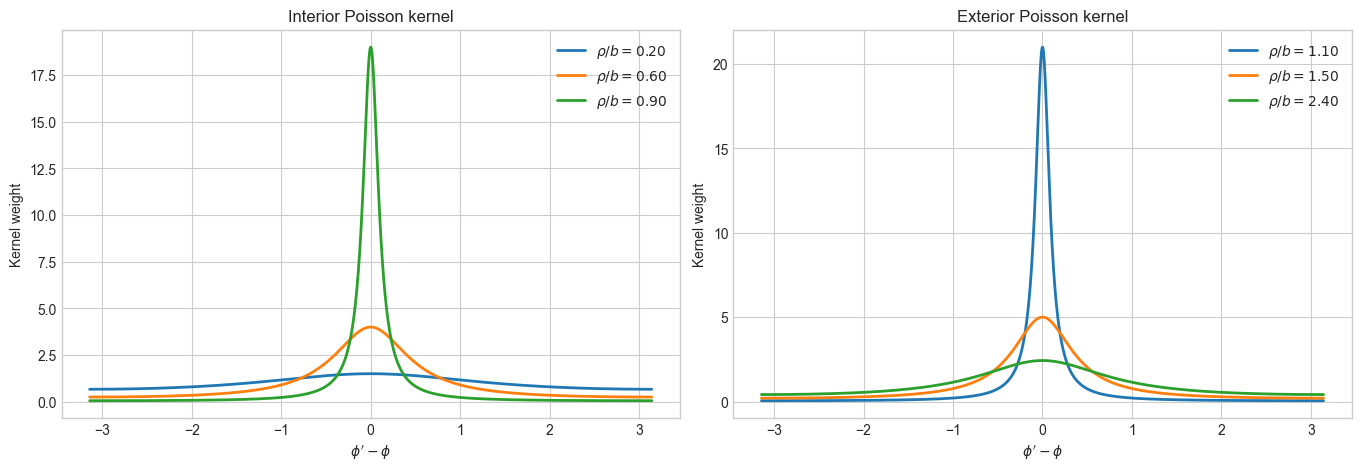

In [7]:
delta = np.linspace(-np.pi, np.pi, 1200)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), constrained_layout=True)

for rho in [0.20 * b, 0.60 * b, 0.90 * b]:
    axes[0].plot(delta, poisson_kernel_interior(rho, delta, b=b), lw=2.0, label=fr"$\rho/b={rho / b:.2f}$")
axes[0].set_title("Interior Poisson kernel")
axes[0].set_xlabel(r"$\phi'-\phi$")
axes[0].set_ylabel("Kernel weight")
axes[0].legend()

for rho in [1.10 * b, 1.50 * b, 2.40 * b]:
    axes[1].plot(delta, poisson_kernel_exterior(rho, delta, b=b), lw=2.0, label=fr"$\rho/b={rho / b:.2f}$")
axes[1].set_title("Exterior Poisson kernel")
axes[1].set_xlabel(r"$\phi'-\phi$")
axes[1].set_ylabel("Kernel weight")
axes[1].legend()

plt.show()


## Takeaway

The content of Jackson 2.12 is that the separated harmonic series for a circular boundary is not just a formal expansion. Once the Fourier coefficients are written as boundary integrals and resummed, the entire solution collapses into a single integral against Poisson's kernel. The kernel gives a precise boundary-weighted average of the prescribed potential.

For the exterior region the mathematics is nearly the same, but the physical regularity condition changes. Instead of keeping the $\rho^n$ terms and rejecting the singular ones, we keep the decaying $(b/\rho)^n$ terms and reject the growing and logarithmic pieces. That is the modification needed to pass from the interior disk to the region between the cylinder and infinity.
